# Analisi esplorativa

In [3]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import cast
from datasets import load_dataset
from matplotlib.ticker import FuncFormatter

dataset = load_dataset('lukebarousse/data_jobs')
df = cast(pd.DataFrame, dataset['train'].to_pandas())
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])


Filtriamo per i ruoli di Data Analyst negli Stati Uniti

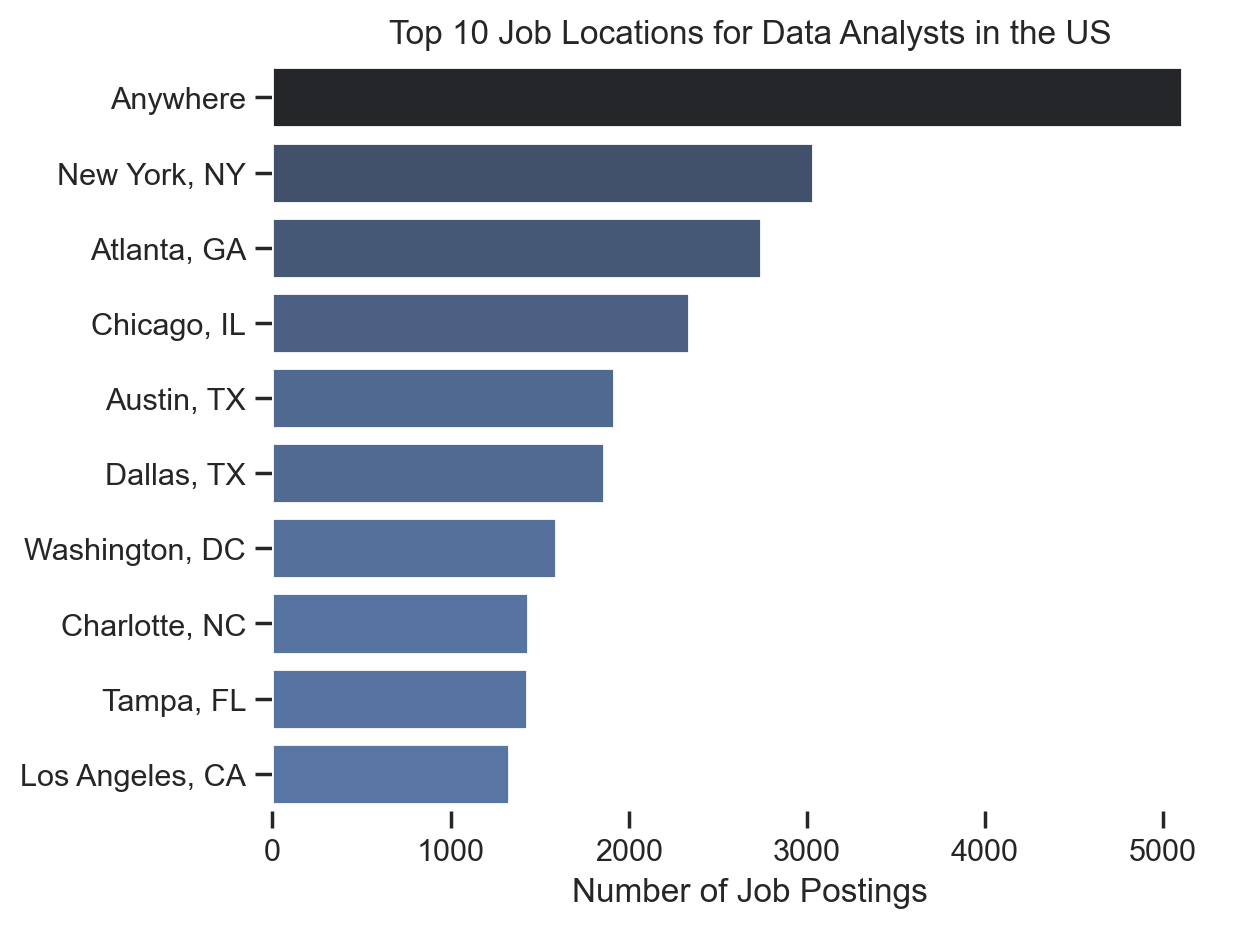

In [19]:
%config InlineBackend.figure_format = 'retina'
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()
df_plot = df_DA_US['job_location'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:b_r', legend=False)
sns.despine(left=True, bottom=True) # rimuove le spine per un look più pulito
plt.xlabel("Number of Job Postings")
plt.ylabel("")
plt.title("Top 10 Job Locations for Data Analysts in the US")
plt.tight_layout()
plt.show()

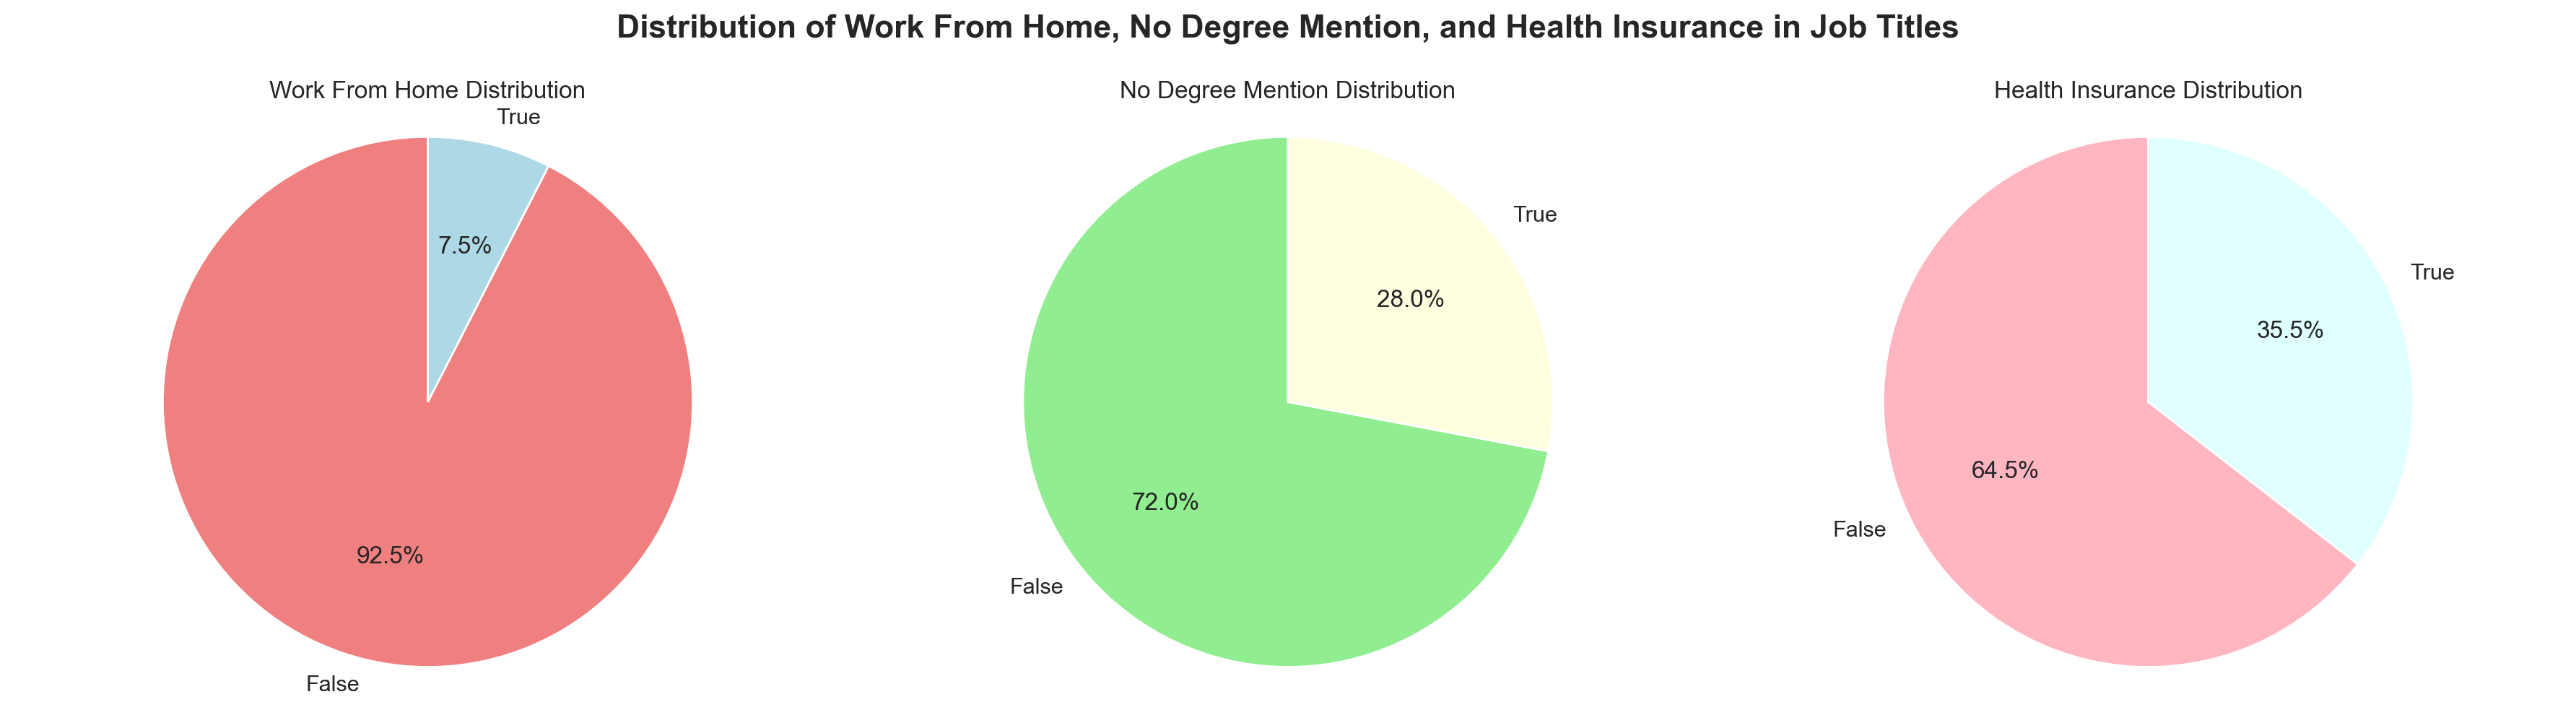

In [18]:
%config InlineBackend.figure_format = 'retina'
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
dict_columns = {
    'job_work_from_home': "Work From Home Distribution",
    'job_no_degree_mention': "No Degree Mention Distribution",
    'job_health_insurance': "Health Insurance Distribution"
}
colors_list = [['lightcoral', 'lightblue'], ['lightgreen', 'lightyellow'], ['lightpink', 'lightcyan']]
for i, (col, title) in enumerate(dict_columns.items()):
    df_DA_US[col].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, title=title, ax=axes[i], colors=colors_list[i])
    axes[i].set_ylabel("")
    axes[i].axis('equal')
fig.suptitle("Distribution of Work From Home, No Degree Mention, and Health Insurance in Job Titles", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

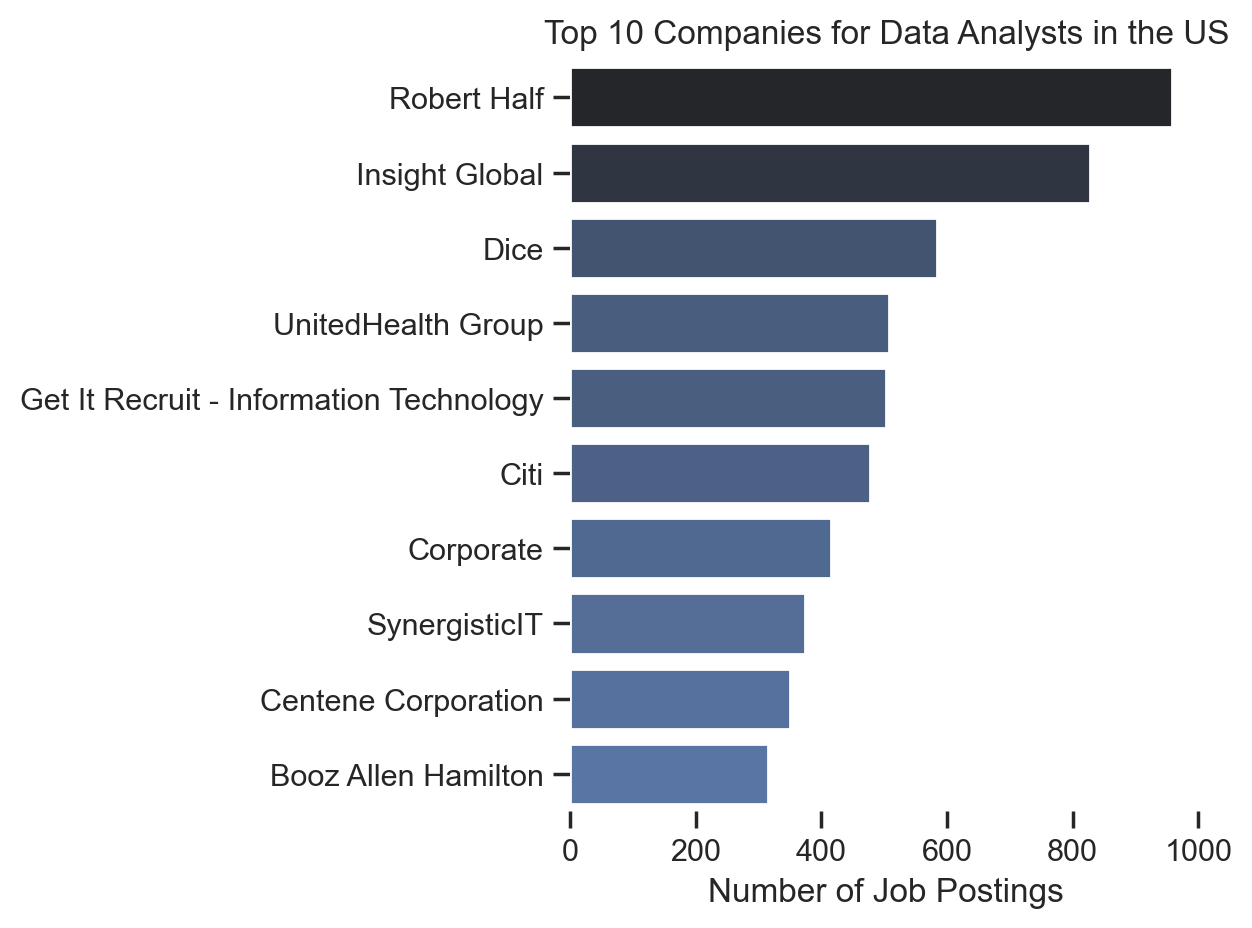

In [20]:
df_plot = df_DA_US['company_name'].value_counts().head(10).to_frame()
sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
sns.despine(left=True, bottom=True) # rimuove le spine per un look più pulito
plt.xlabel("Number of Job Postings")
plt.ylabel("")
plt.title("Top 10 Companies for Data Analysts in the US")
plt.tight_layout()
plt.show()